# Plot the emulation, interpolation, and inference of population parameters with normalising flows using AMAZE

This notebook goes through the plot making for figures 1-6 (and some of the other statistics) presented in 'Exploring the evolution of gravitational-wave emitters with efficient emulation: Constraining the origins of binary black holes using normalising flows' (Colloms et al. 2025)

These plots show the emulation performance of the trained normlising flows, the effect of regularisation on the likelihood of the flow, the inferences results with discrete and continuous inference of the population parameters, and the shape of the inferred population.

To run this notebook, clone the AMAZE codebase (<LINK and version tag>) and install associated necessary conda environment, download the population synthesis data (`models_reduced.hdf5`) from https://doi.org/10.5281/zenodo.4277619, and download the trained normalising flow models from https://doi.org/10.5281/zenodo.14967687

First, we import the necessary packages and functions

In [1]:
import numpy as np
import pandas as pd
import operator
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
import corner
import glob
from tqdm import tqdm
import matplotlib.lines as mlines
from scipy.stats import dirichlet
from scipy.stats import loguniform
from functools import reduce
from matplotlib import gridspec
from matplotlib.transforms import (Bbox, TransformedBbox,
                                   blended_transform_factory)
from mpl_toolkits.axes_grid1.inset_locator import (BboxConnector,
                                                   BboxConnectorPatch,
                                                   BboxPatch)
import sys
sys.path.append('/data/wiay/2297403c/amaze_model_select/AMAZE_model_selection/')
#AMAZE functions
#AMAZE functions
from populations.models import *
from populations.Pop_Flows import FlowModel
from sample.sample import lnlike
#additional functions for inset plot
from zoom_plot import *

/data/wiay/2297403c/conda_envs/amaze/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


And initialise dictionaries to characterise input parameters and plotting styles

In [14]:
#random seed
random_seed=12
np.random.seed(random_seed)

#plot settings
%matplotlib inline
colors = sns.color_palette("colorblind", n_colors=10)
cp = [colors[0], colors[2], colors[4], colors[1], colors[3], colors[6], colors[9], colors[5], colors[8]]
plt.style.use("mpl.sty")

#dictionary to define event parameters, hyperparameters, and channels
_param_dict = {'mchirp' : {'limits':(0,100), 'fullname':'Chirp Mass [$M_\\odot$]'},
    'q' : {'limits':(0,1), 'fullname':'Mass Ratio'},
    'chieff' : {'limits':(-1,1), 'fullname':'Effective Inspiral Spin'},
    'z' : {'limits':(0,10), 'fullname':'Redshift'},
    }
_hyperparam_dict = {'chib' : {'values':{'chi00':0.0, 'chi01':0.1, 'chi02':0.2, 'chi05':0.5},
        'fullname':'$\\chi_\\mathrm{birth}$',
        'transform':'linear'},
    'alphaCE' : {'values':{'alpha02':0.2, 'alpha05':0.5, 'alpha10':1.0, 'alpha20':2.0, 'alpha50':5.0},
        'fullname':'$\\alpha_\\mathrm{CE}$',
        'transform':'log'}
    }
_channels_dict = {
    'CE':  {'parameters':['chib','alphaCE'], 'fullname':'Common Envelope'},
    'CHE': {'parameters':['chib'], 'fullname':'Chemically Homogeneous Evolution'},
    'GC':  {'parameters':['chib'], 'fullname':'Globular Clusters'},
    'NSC': {'parameters':['chib'], 'fullname':'Nuclear Star Clusters'},
    'SMT': {'parameters':['chib'], 'fullname':'Stable Mass Transfer'}
    }

#dictionary to access KDE submodels
_submodels_dict= {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, \
1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}

#plot labels
_param_bounds = {"mchirp": (-1.,70), "q": (0.08,1.01), "chieff": (-0.6,1.), "z": (-0.1,3.5)}
_param_ticks = {"mchirp": [0,10,20,30,40,50,60,70], "q": [0.25,0.5,0.75,1], "chieff": [-0.5,0,0.5,1], "z": [0,0.25,0.5,0.75,1.0,1.25]}
_pdf_bounds = {"mchirp": (0,0.075), "q": (0,32), "chieff": (0,17), "z": (0,4)}
_pdf_ticks = {"mchirp": [0.0,0.025,0.050,0.075], "q": [0,10,20,30], "chieff": [0,4,8,12,16], "z": (0,1,2,3,4)}
_labels_dict = {"mchirp": r"$\mathcal{M}$/$M_{\odot}$", "q": r"$q$", \
"chieff": r"$_{\rm eff}$", "z": r"$z$", "chi00": r"$\chi_\mathrm{b}=0.0$", \
"chi01": r"$\chi_\mathrm{b}=0.1$", "chi02": r"$\chi_\mathrm{b}=0.2$", \
"chi05": r"$\chi_\mathrm{b}=0.5$", "alpha02": r"$\alpha_\mathrm{CE}=0.2$", \
"alpha05": r"$\alpha_\mathrm{CE}=0.5$", "alpha10": r"$\alpha_\mathrm{CE}=1.0$", \
"alpha20": r"$\alpha_\mathrm{CE}=2.0$", "alpha50": r"$\alpha_\mathrm{CE}=5.0$", \
"CE": r"$\texttt{CE}$", "CHE": r"$\texttt{CHE}$", "GC": r"$\texttt{GC}$", \
"NSC": r"$\texttt{NSC}$", "SMT": r"$\texttt{SMT}$", \
"chi_b": r"$\chi_\mathrm{b}$", "alpha_CE": r"$\alpha_\mathrm{CE}$"}
_param_label = [_labels_dict["mchirp"],_labels_dict["q"], _labels_dict["chieff"], _labels_dict["z"]]
_Nsamps = 100000
_channel_label =[r'$\beta_{\mathrm{CE}}$',r'$\beta_{\mathrm{CHE}}$',r'$\beta_{\mathrm{GC}}$',r'$\beta_{\mathrm{NSC}}$',r'$\beta_{\mathrm{SMT}}$']
_channel_label_det =[r'$\beta_{\mathrm{CE}}^{\mathrm{det}}$',r'$\beta_{\mathrm{CHE}}^{\mathrm{det}}$',r'$\beta_{\mathrm{GC}}^{\mathrm{det}}$',\
    r'$\beta_{\mathrm{NSC}}^{\mathrm{det}}$',r'$\beta_{\mathrm{SMT}}^{\mathrm{det}}$']
_beta_det_label = r'$p(\beta^{\mathrm{det}})$'

#path to population synthesis models
_models_path ='/PATH/TO/models_reduced.hdf5'

#figure size
pt = 1./72.27
jour_sizes = {"AAS": {"onecol": 242.26653*pt, "twocol": 242.26653*2*pt},
             }
figure_width = jour_sizes["AAS"]["onecol"]

#corner plot args
_base_corner_kwargs = dict(
    bins=60,
    smooth=0.9,
    #quantiles=[0.16, 0.84],
    levels=(0.5,0.9,0.99),
    plot_density=True,
    plot_datapoints=True,
    fill_contours=True,
    show_titles=False,
    hist_kwargs=dict(density=True,linewidth=.75),
    contour_kwargs=dict(linewidths=1.),
    labels=_param_label,
    hist2d_kwargs= dict(data_kwargs=dict(alpha=0.01))
)

In [ ]:
def get_popsynth_outputs(file_path, chnl, channel_dict, param_dict, spinmag=None):
    deepest_models, hyperparam_pts_per_dim = get_deepest_models(file_path, channel_dict)
    channel_smdls, smdl_indxs_combos = get_channel_smdls(chnl, deepest_models, hyperparam_pts_per_dim)
    popsynth_outputs = read_hdf5(file_path, chnl, channel_smdls, smdl_indxs_combos, param_dict, spinmag)
    return popsynth_outputs

def load_models(channel_label):
    popsynth_outputs = get_popsynth_outputs(_models_path, channel_label, _channels_dict, _param_dict, spinmag=None)
    models_dict = dict.fromkeys(popsynth_outputs.keys())
    weights_dict = dict.fromkeys(popsynth_outputs.keys())
    for key in popsynth_outputs.keys():
        models_dict[key] = popsynth_outputs[key][list(_param_dict.keys())]
        weights_dict[key]= popsynth_outputs[key]['weight']
    return models_dict, weights_dict

# Emulation and Interpolation

## Figure 1
### Corner plot of Flow, KDE, and Popsynth samples for CE channel with χb=0. and alpha_CE=2.

This plot shows the distribution of the binary observables (chirp mass, mass ratio, effective inspiral spin, and redshift) learned by the normalising flow for the common envelope (CE) channel with χb=0 and alpha_CE=2. This is also compared to samples from the KDE, as well as to the original training data. We see that the normalising flow can learn the target data well, and can capture the sharp feature in the effective spin distribution better than the KDE.

In [ ]:
def sample_pop_corner(popsynth_outputs, flow_dir, channel_label, hyperparam_idxs, effectiveNsamps=True, sample_KDE=True):

    print('loading flow and KDE models...')
    channels_dict_subset = {channel_label:_channels_dict[channel_label]}

    #create flow and KDE models
    model_names, flow = get_models(_models_path, channels_dict_subset, _param_dict, _hyperparam_dict,\
         use_flows=True, sensitivity='midhighlatelow', spinmag=None, random_seed=random_seed)
    if sample_KDE:
        _, KDE_models = get_models(_models_path, channels_dict_subset, _param_dict, _hyperparam_dict,\
             use_flows=False, sensitivity='midhighlatelow', spinmag=None, max_samps=None, kde_bandwidth=None, \
                        store_optimal_snrs=False, random_seed=random_seed)

    #load in trained flow
    flow[channel_label].load_model(flow_dir, device='cpu')

    #determine no. effective samples to draw from flow/KDE corresponding to no. effective samples in underlying model
    if effectiveNsamps:
        models_dict, weights_dict = load_models(channel_label)
        weights=weights_dict[tuple(hyperparam_idxs)]
        _Nsamps = int((np.sum(weights))**2/(np.sum(weights**2)))

    #sample flow
    print('sampling flow...')
    conditional = [flow[channel_label].hp_vals[i][hyperparam_idxs[i]] for i in range(flow[channel_label].conditionals)]
    flow_samples = flow[channel_label].sample(np.array(conditional),_Nsamps)

    #sample KDE
    if sample_KDE:
        print('sampling KDE...')
        model_key = [channel_label]
        for i,model_indx in enumerate(hyperparam_idxs):
            smdl_name=list(_hyperparam_dict[list(_hyperparam_dict.keys())[i]]['values'].keys())[model_indx]
            model_key.append(smdl_name)
        kde_smdl = reduce(operator.getitem, model_key, KDE_models)
        kde_samples=kde_smdl.sample(_Nsamps)
        return [flow_samples,kde_samples]
    else:
        return [flow_samples]

def make_pop_corner(channel_label, hyperparam_idxs, flow_dir, conditional=None, plot_KDE=True, outdir='.', testCE=False, justplot=True):

    #get population synthesis samples
    models_dict, weights_dict = load_models(channel_label)

    #get samples from models, either sampling first or loading from file
    if justplot==False:
        samples = sample_pop_corner(models_dict, flow_dir, channel_label, hyperparam_idxs=hyperparam_idxs, sample_KDE=plot_KDE)
    else:
        if testCE:
            flow_samples= np.load(f"{outdir}/data/{channel_label}_flows_cornersample_testCE.npy")
            samples = [flow_samples]
        else:
            flow_samples= np.load(f"{outdir}/data/{channel_label}_flows_cornersample.npy")
            kde_samples = np.load(f"{outdir}/data/{channel_label}_KDEs_cornersample.npy")
            samples = [flow_samples, kde_samples]

    #set kwargs for plot
    model_kwargs = deepcopy(_base_corner_kwargs)
    corner_kwargs_kde = deepcopy(_base_corner_kwargs)
    corner_kwargs_flow = deepcopy(_base_corner_kwargs)

    #set colors for plot
    if testCE:
        kwargs = [model_kwargs, corner_kwargs_flow]
        colors=['C1', 'royalblue']
        labels=['Underlying Model', 'Normalising Flow']
    else:
        kwargs = [model_kwargs, corner_kwargs_kde, corner_kwargs_flow]
        colors=['C1', 'purple', 'royalblue']
        labels=['Underlying Model', 'KDE', 'Normalising Flow']
    
    for i, kwarg in enumerate(kwargs):
        kwarg["color"] = colors[i]
        kwarg["hist_kwargs"]["color"] = colors[i]

    print('plotting samples')
    if len(hyperparam_idxs) > 1:
        dict_key = tuple(hyperparam_idxs)
    else:
        dict_key = hyperparam_idxs
    #plot underlying population synthesis samples
    fig =corner.corner(models_dict[dict_key],  weights=weights_dict[dict_key], **model_kwargs)
    #plot samples from KDE
    if plot_KDE==True:
        corner.corner(samples[1], fig=fig, **corner_kwargs_kde)
    #plot normlaising flow samples
    corner.corner(samples[0], fig=fig, **corner_kwargs_flow)
    #add legend
    plt.legend(
            handles=[
                mlines.Line2D([], [], color=colors[i], label=labels[i])
                for i in range(len(colors))
            ],
            frameon=False,
            bbox_to_anchor=(1, 4), loc="upper right"
        )

    fig.set_size_inches(figure_width*1.5, figure_width*1.5)

    #add inset plot for comparison of the representation of the spike in chi_b
    if plot_KDE==True:
        inset = fig.add_subplot(444)
        ll, bb, ww, hh =inset.get_position().bounds
        inset.set_position([ll-0.2*ww, bb - 0.75*hh, ww, hh])

        inset.hist(samples[0][:,2], density=True,linewidth=.75,bins=300, color=colors[2], histtype='step')
        inset.hist(samples[1][:,2], density=True,linewidth=.75,bins=300, color=colors[1], histtype='step')
        inset.hist(models_dict[tuple(hyperparam_idxs)]['chieff'], weights=weights_dict[tuple(hyperparam_idxs)],density=True,\
            linewidth=.75,bins=300, color=colors[0], histtype='step')
        inset.set_xlim(-0.05,0.1)
        inset.set_xlabel(r"$\chi_{\rm eff}$")
        inset.set_xticks([0., 0.1])
        inset.tick_params(labelsize=8, length=2, pad=0)
        inset.tick_params(
            axis='y',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            right=False,      # ticks along the bottom edge are off
            left=False,         # ticks along the top edge are off
            labelleft=False)
        zoom_effect02(inset, fig.get_axes()[-7], **dict(alpha=0.8, lw=.8))

    return fig, samples

In [ ]:
#Figure 1 - corner plot of samples from the trained normalising flow
fig,samples = make_pop_corner('CE',[0,3], justplot=False, \
    flow_dir='/PATH/TO/flow_models',\
    outdir='.')
plt.show()

## Figure 2
### Corner plot of flow with removed test population for CE channel with chi_b=0.1 and alpha_CE=1.

This plot shows how the normalising flow can interpolate across the dataset, replicating a dataset (orange) that it has not seen during training.
This was used as an example to show the interpolation abilities of the normalising flow, while for inference the whole dataset was used to train the normalising flow.

In [ ]:
#Fig 2 Test CE plot
fig,samples = make_pop_corner('CE',[1,2], plot_KDE=False, testCE=True, justplot=False,\
    flow_dir='/PATH/TO/flow_models/CE_test_population')
plt.show()

## Figure 3
### Slice through the log likelihood, with and without regularisation.

This plot shows the ratio of the log likelihood distribution between the normalising flow represention and the KDE representation of the CE population
model with χb = 0 and αCE = 5, at a slice through chirp mass and mass ratio at effective inspiral spin of 0.05 and redshift of 0.1.

The upper plot shows the ratio without any regularisation, which is at the most extreme in the tails of the distribution (which is represented by the black contours).

With regularisation as used in the inference results, the ratio is greatly reduced in the tails (note the much smaller range in the colorbar scale).

We use regularisation in our inference as it gives a uniform distribution where we do not have enough information from the population synthesis samples. This means that there is no preference between channels in the regions of parameter space where there are no samples for any channel.

In [ ]:
#Fig 3. Log likelihood ratio plot
def calc_llh_ratio_CE(flow_dir, outdir='.'):

    channel_label = 'CE'
    channels_dict_subset = {channel_label:_channels_dict[channel_label]}

    #create flow and KDE models
    print('loading flows/KDEs')
    model_names, flow = get_models(_models_path, channels_dict_subset, _param_dict, _hyperparam_dict,\
         use_flows=True, sensitivity='midhighlatelow', spinmag=None, random_seed=random_seed)
    _, KDE_models = get_models(_models_path, channels_dict_subset, _param_dict, _hyperparam_dict,\
         use_flows=False, sensitivity='midhighlatelow',spinmag=None, max_samps=None, kde_bandwidth=None, \
         store_optimal_snrs=False, random_seed=random_seed)

    #load flow model
    flow[channel_label].load_model(flow_dir, device='cpu')

    #initialise grid of M, q, and p(M,q|chieff,z)
    mchirps = np.linspace(4.,49.9,20)
    qs = np.linspace(0.01,0.99,20)
    p_mchirpq_unreg = np.zeros((20,20))
    p_mchirpq_kde_unreg = np.zeros((20,20))
    p_mchirpq_reg = np.zeros((20,20))
    p_mchirpq_kde_reg = np.zeros((20,20))

    #specify underlying model
    chi_b_id = 0
    alpha_id = 4

    #find log likelihoods for flow and KDE, with and without regularisation
    print('caclulating log likelihoods')
    for  i, m in enumerate(tqdm(mchirps)):
        for j, q in enumerate(qs):
            sample = np.reshape([m, q,0.05,0.2], (1,1,4))
            p_mchirpq_reg[i, j] = lnlike([chi_b_id,alpha_id], sample, flow, _submodels_dict, ['CE'], use_flows=True,\
                 prior_pdf=None, continuous_sampling=False, smallest_N=990903)
            p_mchirpq_kde_reg[i, j] = lnlike([chi_b_id,alpha_id], sample, KDE_models, _submodels_dict, ['CE'], use_flows=False,\
                 prior_pdf=None, continuous_sampling=False, smallest_N=990903)
            
            p_mchirpq_unreg[i, j] = lnlike([chi_b_id,alpha_id], sample, flow, _submodels_dict, ['CE'], use_flows=True,\
                 prior_pdf=None, continuous_sampling=False, smallest_N=None)
            p_mchirpq_kde_unreg[i, j] = lnlike([chi_b_id,alpha_id], sample, KDE_models, _submodels_dict, ['CE'], use_flows=False,\
                 prior_pdf=None, continuous_sampling=False, smallest_N=None)

    #convert to log base 10
    llh_ratio_kde_flow_reg = np.log10(np.exp(p_mchirpq_reg-p_mchirpq_kde_reg))
    llh_ratio_kde_flow_unreg = np.log10(np.exp(p_mchirpq_unreg-p_mchirpq_kde_unreg))

    return mchirps, qs, llh_ratio_kde_flow_reg, llh_ratio_kde_flow_unreg

def plot_llh_ratio_CE(flow_dir, outdir, justplot=False):
    plt.rcParams['figure.figsize'] = [figure_width, figure_width*1.2]
    channel_label = 'CE'
    
    #get plot data
    if justplot:
        mchirps = np.linspace(4.,49.9,20)
        qs = np.linspace(0.01,0.99,20)
        llh_ratio_kde_flow_reg = np.load(f"{outdir}/data/llh_ratio_kde_flow_reg.npy")
        llh_ratio_kde_flow_unreg = np.load(f"{outdir}/data/llh_ratio_kde_flow_unreg.npy")
    else:
        mchirps, qs, llh_ratio_kde_flow_reg, llh_ratio_kde_flow_unreg = calc_llh_ratio_CE(flow_dir, outdir)

    #load popsynth models
    models_dict, weights_dict = load_models(channel_label)
    
    #specify underlying model
    chi_b_id = 0
    alpha_id = 4

    #plot
    print('plotting ratios')
    fig, ax = plt.subplots(2,1)

    for row, ratio in enumerate([llh_ratio_kde_flow_unreg, llh_ratio_kde_flow_reg]):
        cbar_scale = np.max(np.abs(ratio))
        c = ax[row].imshow(np.swapaxes(ratio, 0,1), extent=(mchirps[0], mchirps[-1], qs[0], qs[-1]), origin='lower',\
            vmin=-cbar_scale, vmax=cbar_scale, aspect='auto', cmap='RdBu')
        cbar = fig.colorbar(c, ax=ax[row], cmap='RdBu')
        cbar.set_label(r'log$_{10}$ (p$_\mathrm{flow}/$p$_\mathrm{KDE}$)')

        #find popsynth data in bin around slice
        bin_width = 0.05
        chieffs = models_dict[(chi_b_id,alpha_id)][:]['chieff']
        zs = models_dict[(chi_b_id,alpha_id)][:]['z']
        bin_chieff = np.logical_and(chieffs>0.0 - 2*bin_width,  chieffs< 0.0 + 2*bin_width)
        bin_z = np.logical_and(zs>0.2 - 10*bin_width, zs < 0.2 + 10*bin_width)
        bin_conditions = np.logical_and(bin_chieff, bin_z)

        c = ax[row].imshow(np.swapaxes(ratio,0,1), extent=(mchirps[0], mchirps[-1], qs[0], qs[-1]), origin='lower',\
            vmin=-cbar_scale, vmax=cbar_scale, aspect='auto', zorder=-200, cmap='RdBu')

        #plot popsynth data confidence intervals
        corner.hist2d(np.array(models_dict[(chi_b_id,alpha_id)][bin_conditions]['mchirp']),\
            np.array(models_dict[(chi_b_id,alpha_id)][bin_conditions]['q']), bins =16, \
            levels=(.50, .90, .99), \
            weights=np.array(weights_dict[(chi_b_id,alpha_id)][bin_conditions]), contour_kwargs=dict(linewidths=.5), \
            pcolor_kwargs=dict(alpha=0.0), density=True, ax=ax[row], no_fill_contours=True,\
            plot_datapoints=False)
        ax[row].set_xlim(mchirps[0], mchirps[-1])
        ax[row].set_ylim(qs[0], qs[-1])
        ax[row].set_ylabel(_labels_dict['q'])
        ax[1].set_xlabel(_labels_dict['mchirp'])

    fig.tight_layout(pad=1.3)
    return fig

In [ ]:
fig = plot_llh_ratio_CE(flow_dir='/PATH/TO/flow_models',\
    outdir='.')

# Inference results

We run multiple inference runs, and the samples from the multiple runs are plotted together as the joint inference result. This function returns the combined samples from all the runs given a list of the run filenames.

In [ ]:
def load_result_samps(filenames, Nhyper=2, Nchannels=5, detectable=False):
    """
    Loads hyperposterior samples from list of hdf5 files
    filenames : list, array
    """
    samples_allchains = np.array([])
    for i, filename in enumerate(filenames):
        try:
            result = h5py.File(filename, 'r')
        except:
            print(f'file {filename} not found')
            continue
        if detectable:
            result_key = 'detectable_samples'
        else:
            result_key = 'samples'
        samples_file = result['model_selection'][result_key]['block0_values']
        samples_allchains = np.append(samples_allchains, samples_file)
    samples_allchains = np.reshape(samples_allchains, (-1, Nhyper+Nchannels))

    return samples_allchains

## Figure 4
### Discrete inference results

Before extending the normalising flows to continuous inference we compare the discrete inference results using the normalising flows to a non-interpolating method (KDEs).

Here we show the hyperposteriors on the 5 branching fractions measured with the normalising flows (lines), and the KDEs (filled). The top row shows the selection of natal spin model, and the bottom row that of the common envelope efficiency. We infer negligible contribution to the population from the chi_b=0.2 and chi_b=0.5 models, or the alphaCE=0.2 model (both with normalising flows and KDE model representations), and hence these curves do not show up in the plot.

In [ ]:
#Fig 4. Discrete Result

def make_1D_result_discrete(filenames, second_files=None):
    plt.rcParams['figure.figsize'] = [figure_width*2, figure_width]
    channels = list(_channels_dict.keys())

    Nhyper =2
    _concentration = np.ones(len(channels))
    beta_p0 =  dirichlet.rvs(_concentration, size=100000)
    beta_bins = np.linspace(0,1,45)

    fig, ax_margs = plt.subplots(2,5, gridspec_kw={'wspace': 0.22, 'hspace': 0.5})
    fig.tight_layout(h_pad=3, w_pad=0.05)

    #concatenate samples from multiple files
    samples_allchains = load_result_samps(filenames)
    if second_files:
        samples_allchains_comp = load_result_samps(second_files)

    #loop over astrophysical parameters
    for hyper_idx in [0, 1]:
        #loop over population models and plot hyperposteriors
        for midx, model in _submodels_dict[hyper_idx].items():
            smdl_locs = np.argwhere(samples_allchains[:,hyper_idx]==midx).flatten()
            if second_files:
                comp_smdl_locs = np.argwhere(samples_allchains_comp[:,hyper_idx]==midx).flatten()

            for cidx, channel in enumerate(channels):
                factor = 50/(len(samples_allchains[:, cidx+Nhyper]))
                h, bins, _ = ax_margs[hyper_idx,cidx].hist(samples_allchains[smdl_locs, cidx+Nhyper], \
                    histtype='step', color=cp[midx], bins=beta_bins, ls='-', lw=1.2, \
                    label=_labels_dict[model],\
                    weights=factor*np.ones_like(samples_allchains[smdl_locs, cidx+Nhyper]))
                if second_files:
                    factor_comp = 50/(len(samples_allchains_comp[:, cidx+Nhyper]))
                    h, bins, _ = ax_margs[hyper_idx,cidx].hist(samples_allchains_comp[comp_smdl_locs, cidx+Nhyper], \
                        histtype='stepfilled', color=cp[midx], bins=beta_bins, \
                        alpha=0.4, \
                        weights=factor_comp*np.ones_like(samples_allchains_comp[comp_smdl_locs, cidx+Nhyper]))
                    h, bins, _ = ax_margs[hyper_idx,cidx].hist(samples_allchains_comp[comp_smdl_locs, cidx+Nhyper], \
                        histtype='step', color=cp[midx], bins=beta_bins, \
                        alpha=0.0, weights=factor_comp*np.ones_like(samples_allchains_comp[comp_smdl_locs, cidx+Nhyper]))

        # format plot
        for cidx, (channel, ax_marg) in enumerate(zip(channels, ax_margs.T)):
            #plot prior
            h, bins, _ = ax_marg[hyper_idx].hist(beta_p0[:,cidx], \
                    histtype='step', color='grey', bins=20, alpha=0.7, density=True)

            ax_marg[1].set_xlabel(_channel_label[cidx])
            ax_marg[hyper_idx].set_yscale('log')

            ax_marg[hyper_idx].set_xlim(0,1)
            ax_marg[hyper_idx].set_ylim(1e-4,80)
            if cidx == 0:
                ax_marg[hyper_idx].set_ylabel(r"$p(\beta)$")
            else:
                ax_marg[hyper_idx].tick_params(labelleft=False)
        # legend
        if hyper_idx == 0:
            ax_margs[0,0].legend(loc='lower left', bbox_to_anchor=(.7, 1.02), ncol=4)
        if hyper_idx ==1:
            ax_margs[1,0].legend(loc='lower left', bbox_to_anchor=(-0.05, 1.02), ncol=5)

    plt.subplots_adjust(top=0.85)
    plt.show()

In [ ]:
filenames = glob.glob('/PATH/TO/discrete_GWTC3/flow/*.hdf5')
KDE_filenames = glob.glob('/PATH/TO/discrete_GWTC3/KDEs/*.hdf5')
make_1D_result_discrete(filenames, second_files=KDE_filenames)

## Figure 5
### Continuous inference result

We show the hyperposteriors on the natal spin, common envelope efficiency, the 5 underlying branching fractions (middle row), and the 5 detectable branching fractions (bottom), using GWTC-3 events.

The grey verticle lines in the natal spin and common envelope efficiency subplots show the points in hyperparameter space where the population synthesis data were located.

In [ ]:
#Fig 5. Continuous result
def make_1D_result_continuous(filenames, filenames_det=None):
    channels = list(_channels_dict.keys())
    colors = ['royalblue','lightskyblue','darkblue']
    _concentration = np.ones(len(channels))
    beta_p0 =  dirichlet.rvs(_concentration, size=100000)
    _alpha_CE =list(_hyperparam_dict['alphaCE']['values'].values())
    _chi_b =list(_hyperparam_dict['chib']['values'].values())
    alpha_CE_p0 =  loguniform.rvs(_alpha_CE[0], _alpha_CE[-1], size=100000)
    chib_p0 =  np.random.uniform(0, 0.5, size=100000)
    Nhyper =2

    fig = plt.figure()
    plt.rcParams['figure.figsize'] = [figure_width*2, figure_width*1.5]
    subfigs = fig.subfigures(3, 1, height_ratios=[1.,1., 1.], hspace=0.05, facecolor=(0., 0., 0., 0.))
    ax_margs_det = subfigs[2].subplots(1, 5)
    ax_chibalpha = subfigs[0].subplots(1, 2, gridspec_kw={'wspace': 0.3})
    ax_margs = subfigs[1].subplots(1, 5)
    ax_margs_set = [ax_margs, ax_margs_det]
    channel_labels = [_channel_label,_channel_label_det]


    #add together samples from multiple files
    samples_allchains = load_result_samps(filenames)
    sample_sets = np.array([samples_allchains])
    samples_allchains_detectable = load_result_samps([filenames_det], detectable=True)
    sample_sets = [samples_allchains, samples_allchains_detectable]

    #plot posteriors on chi_b and alpha_CE
    h, bins, _ = ax_chibalpha[0].hist(samples_allchains[:, 0], density=True,\
        histtype='step', color=colors[0], bins=np.linspace(0,0.5,80), ls='-', lw=1.5)
    h, bins, _ = ax_chibalpha[1].hist(samples_allchains[:, 1], density=True,\
        histtype='step', color=colors[0], bins=np.linspace(0,5.,50), ls='-', lw=1.5)

    for i, (samples,axes) in enumerate(zip(sample_sets, ax_margs_set)):
        for cidx, channel in enumerate(channels):
            h, bins, _ = axes[cidx].hist(samples[:,cidx+Nhyper], density=True,\
                histtype='step', color=colors[0], bins=np.linspace(0,1.,45), ls='-', lw=1.5)

    # format plot
    chi_b_lim = ax_chibalpha[0].get_ylim()[1] + 50
    alpha_CE_lim = ax_chibalpha[1].get_ylim()[1] +2
    #plot training lines
    ax_chibalpha[0].vlines(_chi_b, ax_chibalpha[0].get_ylim()[0], chi_b_lim, color='black', alpha=0.5)
    #plot chib prior
    ax_chibalpha[0].hist(chib_p0, \
                histtype='step', color='grey', bins=1, alpha=0.7, density=True, zorder=-1000)
    ax_chibalpha[1].vlines(_alpha_CE, ax_chibalpha[1].get_ylim()[0], alpha_CE_lim, color='black', alpha=0.5)
    #plot alpha_CE prior
    ax_chibalpha[1].hist(alpha_CE_p0, \
                histtype='step', color='grey', bins=20, alpha=0.7, density=True, zorder=-1000)

    ax_chibalpha[0].autoscale(tight=True, axis='y')
    ax_chibalpha[1].autoscale(tight=True, axis='y')
    ax_chibalpha[0].set_xlabel(_labels_dict['chi_b'])
    ax_chibalpha[1].set_xlabel(_labels_dict['alpha_CE'])
    #ax_chibalpha[1].set_xscale('log')
    ax_chibalpha[0].set_ylabel(r'$p($'+_labels_dict['chi_b']+r'$)$')
    ax_chibalpha[1].set_ylabel(r'$p($'+_labels_dict['alpha_CE']+r'$)$')

    for cidx, channel in enumerate(channels):
            #plot prior
            h, bins, _ = ax_margs[cidx].hist(beta_p0[:,cidx], \
                    histtype='step', color='grey', bins=20, alpha=0.7, density=True, zorder=-1000)

    for axes, label, samples in zip(ax_margs_set, channel_labels, sample_sets):
        for i, ax_marg in enumerate(np.append(ax_chibalpha, axes).flatten()):

            #median branching fractions
            q_mid = np.percentile(samples[:, i], 50)
            q_m = q_mid - np.percentile(samples[:, i], 5)
            q_p = np.percentile(samples[:, i], 95) - q_mid

            title_fmt=".2f"
            fmt = "{{0:{0}}}".format(title_fmt).format
            title = r"${{{0}}}_{{-{1}}}^{{+{2}}}$"
            title = title.format(fmt(q_mid), fmt(q_m), fmt(q_p))
            ax_marg.set_yscale('log')
            #ax_marg.set_title(fr'${title}$')

            for cidx, channel in enumerate(channels):
                axes[cidx].set_xlabel(label[cidx])
                axes[cidx].set_xlim(0,1)
                ax_margs_set[0][cidx].set_ylim(1e-4,80)
                ax_margs_set[1][cidx].set_ylim(1e-4,15)
                axes[cidx].get_yaxis().set_tick_params(which='minor', size=0)
                #axes[cidx].set_yticks([1e-1,1e1])
                if cidx == 0:
                    ax_margs_set[0][cidx].set_ylabel(r"$p(\beta)$")
                    ax_margs_set[1][cidx].set_ylabel(r'$p(\beta^{\mathrm{det}})$')
                else:
                    axes[cidx].tick_params(labelleft=False)
    plt.show()

In [ ]:
filenames = glob.glob('/PATH/TO/cont_GWTC3/*.hdf5')
make_1D_result_continuous(filenames,\
     filenames_det='/PATH/TO/cont_detectable_GWTC3/cont_detectable.hdf5')

## Figure 6
### Inferred population in dataspace
### Note that sampling takes substantial runtime - this is reduced by providing `dataspace_samps.hdf5` from https://doi.org/10.5281/zenodo.14967687 in location `{outdir}/data/dataspace_samps.hdf5`

This plot shows the measured distributions of observables from the continuous inference, compared to samples from the default GWTC-3 models (powerlaw+peak in mass, powerlaw in redshift, an identical beta distribution for both spin magnitudes, a mixture of isotropic and normally distributed spin tilts, and a power law in redshift).

Compared to the parametric models, our inferred population has a greater contribution at higher chirp masses, mass ratios around 0.5, and more positive effective inspiral spins.

In [ ]:
#Fig. 6 Dataspace result
def save_dataspace_samps(filenames, flow_dir, outdir='.'):
    channels = list(_channels_dict.keys())
    params=list(_param_dict.keys())

    print('loading results samples')
    hyper_posts = load_result_samps(filenames)

    print('loading flows')
    model_names, flow = get_models(_models_path, _channels_dict, _param_dict, _hyperparam_dict,\
         use_flows=True, sensitivity='midhighlatelow', spinmag=None, random_seed=random_seed)
    for channel in channels:
        flow[channel].load_model(flow_dir, device='cpu')   

    print('sampling over marginalised hyperparameters')
    #Marginalising over hyperposterior samples
    no_total_samps = 1000000
    samps_per_hyperposts = 10
    no_hypersamps = int(no_total_samps/samps_per_hyperposts)

    samps_filled = np.zeros(6, dtype=int)
    channel_samps = [[],[],[],[],[]]

    for i, hyperpost_idx in enumerate(tqdm(np.random.choice(np.arange(np.shape(hyper_posts)[0]), no_hypersamps, replace=False))):
        hyperpost_samp = hyper_posts[hyperpost_idx,:]

        #evauluate channel as weighted choice according to branching fractions
        channel_idx = np.random.choice(np.arange(len(channels)), p=hyperpost_samp[2:])
        channel = channels[channel_idx]

        #sample flow - take log(alphaCE)
        hyperpost_samp[1] = np.log(hyperpost_samp[1])
        samps = flow[channel].sample(np.array(hyperpost_samp[:flow[channel].conditionals]), samps_per_hyperposts)
        
        channel_samps[channel_idx].append(samps)

    #evaluate the cumulative sum of samples with each channel
    no_channel_samps = [np.shape(channel_samps[chnl])[0] for chnl in np.arange(len(channels))]
    samps_filled[:5] = np.cumsum(no_channel_samps, axis=0)*samps_per_hyperposts

    #ordering total samples by channel
    total_samps_ordered = np.zeros((no_total_samps, len(params)))
    for cidx in range(len(channels)):
        channel_samps_red = np.reshape(np.array(channel_samps[cidx]),(-1,len(params)))
        total_samps_ordered[samps_filled[cidx-1]:samps_filled[cidx],:] = channel_samps_red
    
    return total_samps_ordered, samps_filled

def plot_samps_dataspace(filenames=None, flow_dir=None, outdir='.', justplot=False):
    channels = list(_channels_dict.keys())
    params=list(_param_dict.keys())
    
    if justplot==False:
        total_samps_ordered, samps_filled = save_dataspace_samps(filenames, flow_dir, outdir=outdir)
    else:
        samps = h5py.File(f"{outdir}/data/dataspace_samps.hdf5")
        samps['flow_samps'].keys()
        channels = list(_channels_dict.keys())
        channel_samps = [[],[],[],[],[]]
        samps_size = []
        samps_filled = np.zeros(6, dtype=int)
        no_total_samps = 1000000
        for cidx, chnl in enumerate(channels):
            channel_samps[cidx].append(np.array(samps['flow_samps'][chnl]['block0_values']))
            samps_size.append(samps['flow_samps'][chnl]['block0_values'].shape[0])

        samps_filled[:5] = np.cumsum(samps_size, axis=0)
        total_samps_ordered = np.zeros((no_total_samps, 4))

        for cidx in range(len(channels)):
            channel_samps_red = np.reshape(np.array(channel_samps[cidx]),(-1,4))
            total_samps_ordered[samps_filled[cidx-1]:samps_filled[cidx],:] = channel_samps_red

    plt.rcParams["figure.figsize"] = (figure_width*2,figure_width*2/3)
    fig,ax=plt.subplots(1,4)
    cmap = plt.colormaps['plasma']
    colors = cmap(np.linspace(0, 1, 6))

    print('loading parametric samples')
    comb_intrins_samps = pd.read_hdf('/PATH/TO/GWTC3_intrins_samps_zmax1_35.hdf5', key='all_intrins_samps')
    mchirp_samps = comb_intrins_samps['m1']*(comb_intrins_samps['q']**3/(1+comb_intrins_samps['q']))
    chieff_samps = ((comb_intrins_samps['chi_1']*comb_intrins_samps['costilt_1'])+(comb_intrins_samps['q']*comb_intrins_samps['chi_2']*comb_intrins_samps['costilt_2']))\
    /(1+comb_intrins_samps['q'])

    no_total_samps = np.shape(total_samps_ordered)[0]
    PLPP_samps = [mchirp_samps, comb_intrins_samps['q'], chieff_samps, comb_intrins_samps['z']]
    no_bins=50
    bins =np.array([np.linspace(_param_bounds[pidx][0],_param_bounds[pidx][1],no_bins) for pidx in params])
    ax_ylims = [0.6*no_total_samps,0.2*no_total_samps,0.6*no_total_samps,0.12*no_total_samps]
    mask_min = [np.min(total_samps_ordered[:,0]), 0,-1,0]
    mask_max = [100, 1,1,1.35]

    for cidx, channel in enumerate(channels):
        for pidx,param in enumerate(params):
            ax[pidx].hist(total_samps_ordered[samps_filled[cidx-1]:samps_filled[cidx],pidx], color=colors[cidx], histtype='step', bins=bins[pidx], lw=1,\
                label=channel)

    for pidx,param in enumerate(params):
        ax[pidx].hist(total_samps_ordered[:,pidx], color='slategrey', histtype='stepfilled', bins=bins[pidx], lw=1,\
            zorder=-1000, ls='-', label='Total', alpha=.6,)
        mask = np.logical_and(mask_min[pidx]<total_samps_ordered[:,pidx],total_samps_ordered[:,pidx]<mask_max[pidx])
        ax[pidx].hist(PLPP_samps[pidx], color='deeppink', histtype='step',\
            weights=np.ones_like(PLPP_samps[pidx])*len(total_samps_ordered[mask,pidx])/len(PLPP_samps[pidx]),\
            bins=bins[pidx], lw=1, ls='-', label='Parametric', zorder=-100)
        ax[pidx].set_yscale('log')
        ax[pidx].set_xlabel(_labels_dict[param])
        ax[pidx].set_ylim(5,ax_ylims[0])
        ax[pidx].set_xlim(_param_bounds[param][0],_param_bounds[param][1])
        if pidx>0:
            ax[pidx].tick_params(labelleft=False)
    ax[0].set_ylabel('No. samples')
    plt.legend(loc='lower center', bbox_to_anchor=(-1.4, 1.02), ncol=7, columnspacing=1., frameon=False)
    fig.subplots_adjust( left=None, bottom=None,  right=None, top=None, wspace=None, hspace=None)
    fig.tight_layout(pad=1.3)
    plt.show()

In [ ]:
filenames = glob.glob('/PATH/TO/cont_GWTC3/*.hdf5')
plot_samps_dataspace(filenames, flow_dir='/PATH/TO/flow_models',\
     outdir='.', justplot=True)

# Auxillery Data

Here we show some auxillery data from the normalising flows and the KDEs - the loss plots used to evuated the training of the flows, and the KL and KS statistics between the flows and the KDEs.

In [ ]:
#load flows and KDEs
channel_label = 'CE'
flow_dir = '/PATH/TO/flow_models/'
channels_dict_subset = {channel_label:_channels_dict[channel_label]}

#load underlying models
popsynth_outputs = get_popsynth_outputs(_models_path, channel_label, _channels_dict, _param_dict, spinmag=None)

#create flow and KDE models
print('loading flows/KDEs')
model_names, flow = get_models(_models_path, channels_dict_subset, _param_dict, _hyperparam_dict,\
      use_flows=True, sensitivity='midhighlatelow', spinmag=None, random_seed=random_seed)
_, KDE_models = get_models(_models_path, channels_dict_subset, _param_dict, _hyperparam_dict,\
     use_flows=False, sensitivity='midhighlatelow', spinmag=None, max_samps=None, kde_bandwidth=None, \
     store_optimal_snrs=False, random_seed=random_seed)

#load flow model
flow[channel_label].load_model(flow_dir, device='cpu')

#load underlying models
models_dict, weights_dict = load_models(channel_label)

## Plot Flow history
After the flow has trained, we can evaluate that it has successfully trained to the best of the network ability. The loss should have plateaued, and the validation loss should follow a similar evolution to the training loss through training. Here we plot the training and validation loss for the normalising flow for the CE channel. The loss history is similarly stored in `{channel_label}_loss_history.csv` in `flow_models.tar.gz` for the other four formation channels.

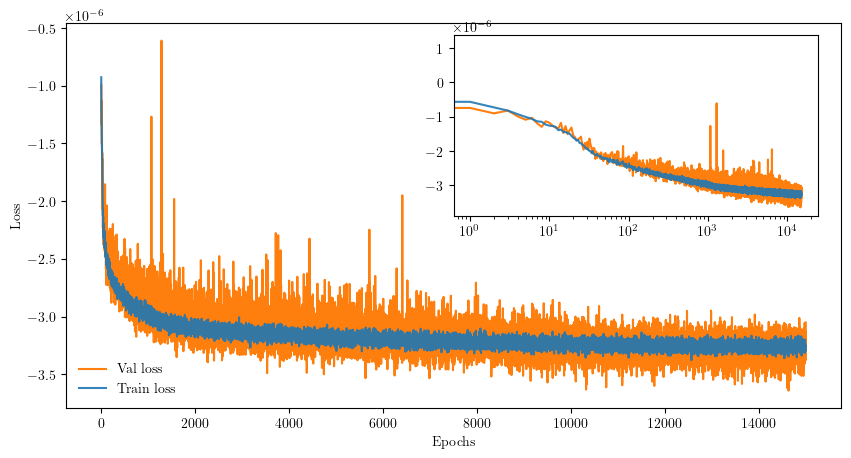

In [17]:
loss = pd.read_csv(f'{flow_dir}/CE_loss_history.csv', usecols=(1,2), delimiter=',')
#loss plot
fig, ax = plt.subplots(figsize = (10,5))
ax.plot(loss['val'][5:], label = 'Val loss', color='tab:orange')
ax.plot(loss['train'][5:], label = 'Train loss', color='tab:blue', alpha=0.9)
ax.set_ylabel('Loss', fontsize=10)
ax.set_xlabel('Epochs', fontsize=10)
ax.tick_params(axis='both', labelsize=10)
text = ax.yaxis.get_offset_text()
text.set_size(10)
ax.legend(loc = 'lower left', prop={'size':10})

#inset log plot
axins = ax.inset_axes([0.5, 0.5, 0.47, 0.47])
valloss = np.asarray(loss['val'][1:])
trainloss = np.asarray(loss['train'][1:])
axins.plot(valloss, color='tab:orange')
axins.plot(trainloss, color='tab:blue', alpha=0.9)
axins.set_xscale('log')
axins.tick_params(axis='both', labelsize=10)
text = axins.yaxis.get_offset_text()
plt.show()
text.set_size(10)

## Kullback–Leibler (KL) divergences

This caclulates the difference in KL divergence between the flow and and the KDE across the subpopulations for a given channel.

Note that due to long runtimes, we reduce the number of samples used to evaluate the KL from 10000 to 100 to showcase this method.

In [ ]:
# KLs
chi_b = [0.0,0.1,0.2,0.5]
alpha_CE = [0.2,0.5,1.0,2.,5.]
no_samples = 100

def calc_KL(channel_label):
    #read in popsynth models
    models_dict, weights_dict = load_models(channel_label)

    flow[channel_label].load_model(flow_dir, device='cpu')

    if channel_label == 'CE':
        flow_KDE_KL = np.zeros((4,5))
        KDE_flow_KL = np.zeros((4,5))
        model_samples = np.zeros((4,5,no_samples,4))
        model_weights = np.zeros((4,5,no_samples))

        #randomly choosing samples at which to evaluate the probability distributions
        for chi_b_id, xb in enumerate(chi_b):
            for alpha_id, a in enumerate(alpha_CE):
                model_samples_idx = np.random.choice(np.shape(models_dict[(chi_b_id,alpha_id)])[0], no_samples)
                model_samples[chi_b_id,alpha_id,:,:] = np.array(models_dict[(chi_b_id,alpha_id)])[model_samples_idx]
                model_weights[chi_b_id,alpha_id,:] = np.array(weights_dict[(chi_b_id,alpha_id)])[model_samples_idx]

        print(f'cacluating flow||models and KDE||models given the model observations')
        flow_KL = np.zeros((4,5))
        KDE_KL = np.zeros((4,5))
        for chi_b_id, xb in tqdm(enumerate(chi_b)):
            for alpha_id, a in enumerate(alpha_CE):
                p_flow = flow[channel_label](np.reshape(model_samples[chi_b_id,alpha_id],(no_samples,1,4)), np.array([xb,np.log(a)]), 990903)
                flow_KL[chi_b_id,alpha_id] = -np.mean(p_flow)
                p_kde = KDE_models[channel_label][_submodels_dict[0][chi_b_id]][_submodels_dict[1][alpha_id]](np.reshape(model_samples[chi_b_id,alpha_id],(no_samples,1,4)), 990903)
                KDE_KL[chi_b_id,alpha_id] = -np.mean(np.log(p_kde))
    else:
        flow_KDE_KL = np.zeros((4))
        KDE_flow_KL = np.zeros((4))
        model_samples = np.zeros((4,no_samples,4))
        model_weights = np.zeros((4,no_samples))

        for chi_b_id, xb in enumerate(chi_b):
            model_samples_idx = np.random.choice(np.shape(models_dict[(chi_b_id)])[0], no_samples)#, \
                #p=weights_dict[(chi_b_id,alpha_id)]/np.sum(weights_dict[(chi_b_id,alpha_id)]))
            model_samples[chi_b_id,:,:] = np.array(models_dict[(chi_b_id)])[model_samples_idx]
            model_weights[chi_b_id,:] = np.array(weights_dict[(chi_b_id)])[model_samples_idx]

        flow_KL = np.zeros((4))
        KDE_KL = np.zeros((4))
        for chi_b_id, xb in tqdm(enumerate(chi_b)):
            p_flow = flow[channel_label](np.reshape(model_samples[chi_b_id],(no_samples,1,4)), np.array([xb]), 990903)
            flow_KL[chi_b_id] = -np.mean(p_flow)
            p_kde = KDE[channel_label][submodels_dict[0][chi_b_id]](np.reshape(model_samples[chi_b_id],(no_samples,1,4)), 990903)
            KDE_KL[chi_b_id] = -np.mean(np.log(p_kde))
    return flow_KL - KDE_KL

In [ ]:
KLs = calc_KL('CE')

In [ ]:
print(f'The mean difference in KL divergences for the CE channel is {np.mean(KLs)}')

## Kolmogorov–Smirnov (KS) test

This gives the mean KS test ratio between the KDE and flow representation of the effective spin distribution for the CE channel. The KS test is ~10 times larger for the KDEs, indicating that the flow distribution is closer to the underlying distribution.

In [ ]:
from scipy.stats import kstest

ks_flows = np.zeros((4,5))
ks_kdes = np.zeros((4,5))

for chib_id, xb in enumerate(flow['CE'].hp_vals[0]):
    for alpha_id, a, in enumerate(flow['CE'].hp_vals[1]):
        flow_samps = flow['CE'].sample(np.array([xb,a]), N=100000)
        KDE_samps = KDE_models['CE'][_submodels_dict[0][chib_id]][_submodels_dict[1][alpha_id]].sample(100000)
        model_samps=models_dict[(chib_id,alpha_id)][:]['chieff']
        weighted_samps = np.random.choice(model_samps, 100000, p=np.array(weights_dict[(chib_id,alpha_id)])/np.sum(weights_dict[(chib_id,alpha_id)]))
        ks_flows[chib_id,alpha_id]=(kstest(weighted_samps, flow_samps[:,2]))[0]
        ks_kdes[chib_id,alpha_id]=(kstest(weighted_samps, KDE_samps[:,2]))[0]
        
print(f'The mean ratio in KS test for the chi_eff distribution of the CE channel is {np.mean(ks_kdes/ks_flows)}')